# Micro Proyecto 2: Clasificacion de textos segun los Objetivos de Desarrollo Sostenible (ODS)

**Curso:** Machine Learning No Supervisado — Universidad de los Andes  
**Objetivo:** Desarrollar una solucion basada en tecnicas de procesamiento de lenguaje natural (NLP) y machine learning que permita clasificar automaticamente textos en espanol segun los 17 Objetivos de Desarrollo Sostenible (ODS) de la ONU.

**Enfoque del proyecto:**
1. Preparacion y limpieza de textos en espanol mediante un pipeline de procesamiento.
2. Representacion vectorial de los textos usando dos enfoques: **TF-IDF** (Bolsa de Palabras) y **Word2Vec** (embeddings semanticos).
3. Reduccion de dimensionalidad con la tecnica adecuada para cada representacion: **TruncatedSVD** para TF-IDF (matrices dispersas) y **PCA** para Word2Vec (embeddings densos). Se justifica por que las combinaciones cruzadas no son apropiadas.
4. Construccion y comparacion de **2 algoritmos de clasificacion**: Regresion Logistica y SVM.
5. Busqueda de hiperparametros y evaluacion con metricas adecuadas.
6. Demostracion del desempeno con textos del conjunto de prueba.

## 1. Configuracion del entorno e importacion de librerias

**Justificacion:** Importamos todas las librerias necesarias al inicio para tener una vision clara de las dependencias del proyecto. Cada libreria cumple un rol especifico:
- **pandas/numpy**: manipulacion de datos y operaciones numericas.
- **matplotlib/seaborn**: visualizacion de datos y resultados.
- **sklearn**: pipeline de preprocesamiento, vectorizacion TF-IDF, reduccion de dimensionalidad, modelos de clasificacion y metricas de evaluacion.
- **nltk**: lista de stopwords en espanol y herramientas de procesamiento de texto.
- **gensim**: entrenamiento del modelo Word2Vec para representacion semantica de palabras.
- **re**: expresiones regulares para limpieza de texto.
- **joblib**: serializacion del modelo final para despliegue.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Sklearn - Preprocesamiento y Vectorizacion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Sklearn - Reduccion de dimensionalidad
from sklearn.decomposition import TruncatedSVD, PCA

# Sklearn - Modelos de clasificacion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Sklearn - Metricas
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)

# Word2Vec
from gensim.models import Word2Vec

# Serializacion
import joblib

# Descargar recursos NLTK
nltk.download('stopwords', quiet=True)

# Configuracion de visualizacion
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 2. Carga y exploracion del conjunto de datos

**Justificacion:** Antes de cualquier transformacion, es fundamental entender la estructura y caracteristicas del dataset. Esto nos permite identificar posibles problemas (datos faltantes, desbalance de clases, textos muy cortos o muy largos) y tomar decisiones informadas en los pasos siguientes.

In [2]:
# Cargar el dataset
df = pd.read_excel('data.xlsx')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nPrimeras 3 filas:")
df.head(3)

Dimensiones del dataset: (9656, 2)
Columnas: ['textos', 'ODS']

Tipos de datos:
textos    object
ODS        int64
dtype: object

Valores nulos:
textos    0
ODS       0
dtype: int64

Primeras 3 filas:


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13


In [3]:
# Diccionario de nombres de los ODS
ODS_NOMBRES = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educacion de calidad",
    5: "Igualdad de genero",
    6: "Agua limpia y saneamiento",
    7: "Energia asequible y no contaminante",
    8: "Trabajo decente y crecimiento economico",
    9: "Industria, innovacion e infraestructura",
    10: "Reduccion de las desigualdades",
    11: "Ciudades y comunidades sostenibles",
    12: "Produccion y consumo responsables",
    13: "Accion por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones solidas"
}

# Distribucion de clases
print("Distribucion de textos por ODS:\n")
distribucion = df['ODS'].value_counts().sort_index()
for ods, count in distribucion.items():
    print(f"  ODS {ods:2d} - {ODS_NOMBRES[ods]:45s} | {count:4d} textos")
print(f"\n  {'Total':50s} | {len(df):4d} textos")

Distribucion de textos por ODS:

  ODS  1 - Fin de la pobreza                             |  505 textos
  ODS  2 - Hambre cero                                   |  369 textos
  ODS  3 - Salud y bienestar                             |  894 textos
  ODS  4 - Educacion de calidad                          | 1025 textos
  ODS  5 - Igualdad de genero                            | 1070 textos
  ODS  6 - Agua limpia y saneamiento                     |  695 textos
  ODS  7 - Energia asequible y no contaminante           |  787 textos
  ODS  8 - Trabajo decente y crecimiento economico       |  446 textos
  ODS  9 - Industria, innovacion e infraestructura       |  343 textos
  ODS 10 - Reduccion de las desigualdades                |  352 textos
  ODS 11 - Ciudades y comunidades sostenibles            |  607 textos
  ODS 12 - Produccion y consumo responsables             |  312 textos
  ODS 13 - Accion por el clima                           |  464 textos
  ODS 14 - Vida submarina                   

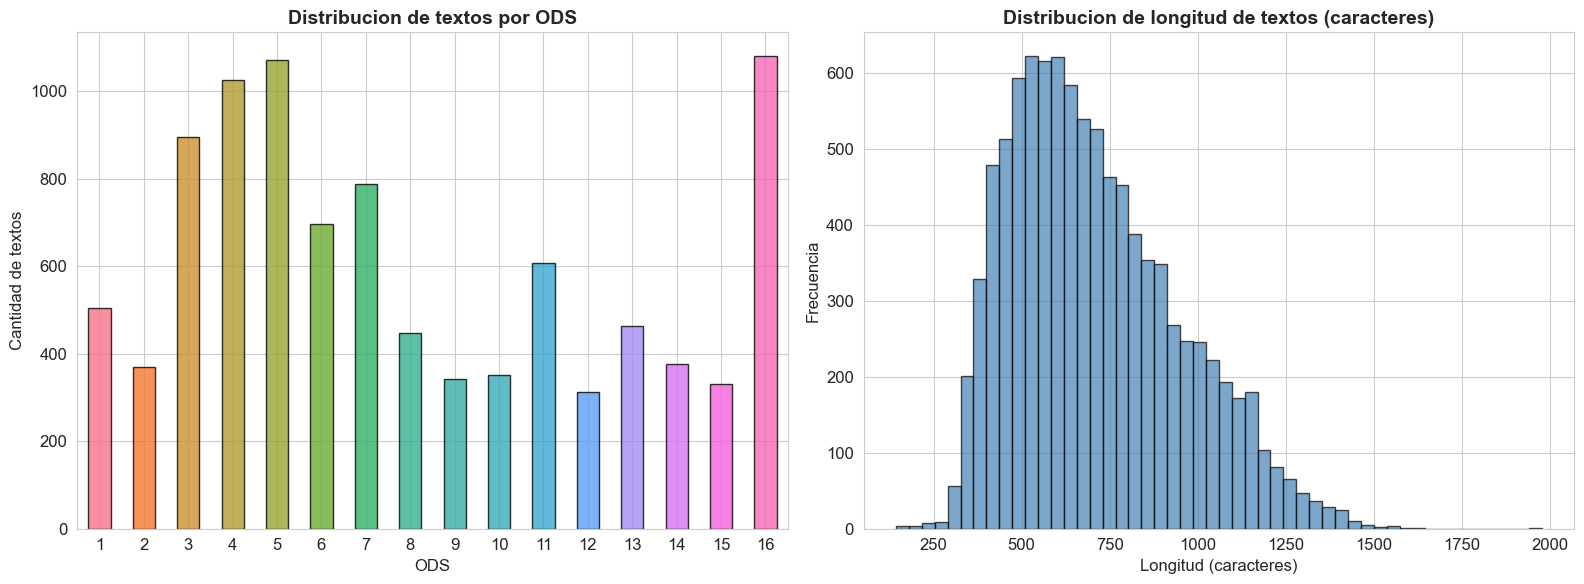


Estadisticas de longitud de textos:
  Promedio: 709 caracteres
  Minimo:   143 caracteres
  Maximo:   1977 caracteres
  Mediana:  669 caracteres


In [4]:
# Visualizacion de la distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico de barras
colors = sns.color_palette("husl", n_colors=16)
distribucion.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribucion de textos por ODS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ODS')
axes[0].set_ylabel('Cantidad de textos')
axes[0].tick_params(axis='x', rotation=0)

# Estadisticas de longitud de texto
df['longitud'] = df['textos'].str.len()
df['longitud'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribucion de longitud de textos (caracteres)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitud (caracteres)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"\nEstadisticas de longitud de textos:")
print(f"  Promedio: {df['longitud'].mean():.0f} caracteres")
print(f"  Minimo:   {df['longitud'].min()} caracteres")
print(f"  Maximo:   {df['longitud'].max()} caracteres")
print(f"  Mediana:  {df['longitud'].median():.0f} caracteres")

## 3. Pipeline de preprocesamiento de texto

**Justificacion de cada paso del pipeline:**

1. **Conversion a minusculas:** Unificamos la representacion para que "Pobreza" y "pobreza" se traten como la misma palabra, reduciendo la dimensionalidad del vocabulario.
2. **Eliminacion de caracteres especiales, numeros y puntuacion:** Estos elementos generalmente no aportan informacion semantica relevante para la clasificacion por ODS y generan ruido en la representacion vectorial.
3. **Tokenizacion:** Dividimos el texto en palabras individuales (tokens) para poder procesarlas de forma independiente.
4. **Eliminacion de stopwords en espanol:** Palabras como "de", "la", "que", "en" son muy frecuentes pero no discriminan entre categorias. Su eliminacion reduce el ruido y la dimensionalidad.
5. **Stemming (SnowballStemmer para espanol):** Reducimos las palabras a su raiz (e.g., "educacion", "educativo", "educar" -> "educ"), lo cual agrupa variantes morfologicas y reduce la dimension del vocabulario. Usamos SnowballStemmer porque soporta espanol de forma nativa.

**Sobre la construccion como Pipeline de sklearn:** Encapsulamos el preprocesamiento como un `TransformerMixin` compatible con sklearn. Esto permite integrarlo limpiamente en pipelines, garantiza reproducibilidad y facilita el despliegue posterior (e.g., en Streamlit).

In [5]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Transformador personalizado de sklearn para preprocesar textos en espanol.
    Aplica: minusculas -> eliminacion de caracteres especiales -> tokenizacion ->
    eliminacion de stopwords -> stemming.
    """
    def __init__(self):
        self.stemmer = SnowballStemmer('spanish')
        self.stop_words = set(stopwords.words('spanish'))

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self._preprocess(text) for text in X]

    def _preprocess(self, text):
        # 1. Convertir a minusculas
        text = text.lower()
        # 2. Eliminar caracteres especiales, numeros y puntuacion (conservar solo letras y espacios)
        text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
        # 3. Tokenizar (dividir por espacios)
        tokens = text.split()
        # 4. Eliminar stopwords y 5. Aplicar stemming
        tokens = [self.stemmer.stem(word) for word in tokens
                  if word not in self.stop_words and len(word) > 2]
        return ' '.join(tokens)

# Instanciar y probar el preprocesador
preprocessor = TextPreprocessor()

# Ejemplo con un texto del dataset
ejemplo_original = df['textos'].iloc[0]
ejemplo_procesado = preprocessor.transform([ejemplo_original])[0]

print("EJEMPLO DE PREPROCESAMIENTO")
print("=" * 80)
print(f"\nTexto original (primeros 300 chars):\n{ejemplo_original[:300]}...")
print(f"\nTexto procesado (primeros 300 chars):\n{ejemplo_procesado[:300]}...")

EJEMPLO DE PREPROCESAMIENTO

Texto original (primeros 300 chars):
"Aprendizaje" y "educación" se consideran sinónimos de escolarización formal. Las organizaciones auxiliares, como las editoriales de educación, las juntas examinadoras y las organizaciones de formación de docentes, se consideran extensiones de los acuerdos establecidos por los gobiernos. Este marco ...

Texto procesado (primeros 300 chars):
aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez inadecu...


In [6]:
# Aplicar preprocesamiento a todos los textos
print("Preprocesando todos los textos...")
textos_procesados = preprocessor.transform(df['textos'].values)
print(f"Textos procesados: {len(textos_procesados)}")

# Verificar que no haya textos vacios despues del preprocesamiento
textos_vacios = sum(1 for t in textos_procesados if len(t.strip()) == 0)
print(f"Textos vacios despues del preprocesamiento: {textos_vacios}")

# Separar features y target
X = textos_procesados
y = df['ODS'].values

Preprocesando todos los textos...
Textos procesados: 9656
Textos vacios despues del preprocesamiento: 0


## 4. Division del conjunto de datos (Train/Test Split)

**Justificacion:** Dividimos el dataset en 80% entrenamiento y 20% prueba usando `stratify=y` para preservar la proporcion de cada clase ODS en ambos conjuntos. Esto es especialmente importante dado el desbalance de clases observado (ODS 12 tiene ~312 textos vs ODS 16 con ~1080). Sin estratificacion, las clases minoritarias podrian quedar subrepresentadas en el conjunto de prueba, generando evaluaciones poco fiables.

In [7]:
# Division estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Conjunto de entrenamiento: {len(X_train)} textos")
print(f"Conjunto de prueba:        {len(X_test)} textos")
print(f"\nDistribucion en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  ODS {u:2d}: {c:4d} ({c/len(y_train)*100:.1f}%)")

# Guardar tambien los indices originales para la demostracion final
_, X_test_orig, _, _ = train_test_split(
    df['textos'].values, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Conjunto de entrenamiento: 7724 textos
Conjunto de prueba:        1932 textos

Distribucion en entrenamiento:
  ODS  1:  404 (5.2%)
  ODS  2:  295 (3.8%)
  ODS  3:  715 (9.3%)
  ODS  4:  820 (10.6%)
  ODS  5:  856 (11.1%)
  ODS  6:  556 (7.2%)
  ODS  7:  629 (8.1%)
  ODS  8:  357 (4.6%)
  ODS  9:  274 (3.5%)
  ODS 10:  282 (3.7%)
  ODS 11:  485 (6.3%)
  ODS 12:  250 (3.2%)
  ODS 13:  371 (4.8%)
  ODS 14:  302 (3.9%)
  ODS 15:  264 (3.4%)
  ODS 16:  864 (11.2%)


## 5. Representacion vectorial de textos

Utilizamos dos enfoques complementarios para convertir los textos en vectores numericos que los algoritmos de ML puedan procesar:

### 5a. TF-IDF (Term Frequency - Inverse Document Frequency)

**Justificacion:** TF-IDF es el enfoque clasico de Bolsa de Palabras (BoW) con pesado inteligente. A diferencia de un conteo simple de frecuencias, TF-IDF penaliza las palabras que aparecen en muchos documentos (como terminos genericos) y premia las palabras distintivas de cada documento. Esto es ideal para clasificacion de textos porque realza los terminos que realmente diferencian un ODS de otro.

Configuramos `max_features=10000` para limitar el vocabulario a las 10,000 palabras mas informativas, controlando la dimensionalidad. Usamos `sublinear_tf=True` para aplicar escalado logaritmico a la frecuencia de terminos, lo que reduce el impacto de palabras repetitivas dentro de un mismo texto.

In [8]:
# Vectorizacion TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    sublinear_tf=True,       # Escalado logaritmico de TF
    ngram_range=(1, 2),      # Unigramas y bigramas para capturar frases relevantes
    min_df=3,                # Ignorar terminos que aparecen en menos de 3 documentos
    max_df=0.95              # Ignorar terminos que aparecen en mas del 95% de documentos
)

# Ajustar solo con datos de entrenamiento para evitar data leakage
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")
print(f"Matriz TF-IDF de prueba:        {X_test_tfidf.shape}")
print(f"Tipo de matriz: {type(X_train_tfidf).__name__} (dispersa/sparse)")
print(f"\nEjemplo - 10 palabras con mayor IDF (mas discriminativas):")
feature_names = tfidf_vectorizer.get_feature_names_out()
idf_scores = tfidf_vectorizer.idf_
top_idf_idx = np.argsort(idf_scores)[-10:]
for idx in top_idf_idx:
    print(f"  '{feature_names[idx]}': IDF = {idf_scores[idx]:.3f}")

Matriz TF-IDF de entrenamiento: (7724, 10000)
Matriz TF-IDF de prueba:        (1932, 10000)
Tipo de matriz: csr_matrix (dispersa/sparse)

Ejemplo - 10 palabras con mayor IDF (mas discriminativas):
  'lfpr': IDF = 8.566
  'esteriliz': IDF = 8.566
  'leds': IDF = 8.566
  'kazaj': IDF = 8.566
  'jpy': IDF = 8.566
  'relacion drog': IDF = 8.566
  'relacion preci': IDF = 8.566
  'vre': IDF = 8.566
  'ontolog': IDF = 8.566
  'delit cibernet': IDF = 8.566


### 5b. Word2Vec (Embeddings semanticos)

**Justificacion:** A diferencia de TF-IDF (que trata cada palabra como una dimension independiente), Word2Vec aprende representaciones densas donde las palabras con significados similares tienen vectores cercanos en el espacio. Esto permite capturar relaciones semanticas (e.g., "pobreza" y "desigualdad" tendran vectores similares).

Entrenamos Word2Vec sobre nuestro corpus (los textos de entrenamiento) para que los embeddings reflejen el vocabulario especifico del dominio de los ODS. Representamos cada documento como el **promedio de los vectores** de sus palabras, una estrategia simple pero efectiva que preserva la informacion semantica global del texto.

Parametros clave:
- `vector_size=200`: dimension del embedding (200 ofrece buen balance entre expresividad y eficiencia).
- `window=5`: contexto de 5 palabras alrededor para capturar relaciones locales.
- `min_count=3`: ignorar palabras muy raras (menos de 3 apariciones) que no tienen suficiente contexto para un buen embedding.

In [9]:
# Tokenizar textos para Word2Vec (lista de listas de palabras)
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# Entrenar modelo Word2Vec solo con datos de entrenamiento
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=200,
    window=5,
    min_count=3,
    workers=4,
    seed=RANDOM_STATE,
    epochs=20
)

print(f"Vocabulario Word2Vec: {len(w2v_model.wv)} palabras")
print(f"Dimension de embeddings: {w2v_model.wv.vector_size}")

# Funcion para convertir un documento en su vector promedio
def document_vector(tokens, model):
    """Calcula el vector promedio de un documento a partir de los embeddings de sus palabras."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Generar matrices de features Word2Vec
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_test_tokens])

print(f"\nMatriz Word2Vec de entrenamiento: {X_train_w2v.shape}")
print(f"Matriz Word2Vec de prueba:        {X_test_w2v.shape}")

# Verificar palabras similares como sanity check
print("\nPalabras mas similares a 'pobrez' (raiz de pobreza):")
try:
    similares = w2v_model.wv.most_similar('pobrez', topn=5)
    for palabra, score in similares:
        print(f"  {palabra}: {score:.3f}")
except KeyError:
    print("  (palabra no encontrada en el vocabulario)")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulario Word2Vec: 6258 palabras
Dimension de embeddings: 200

Matriz Word2Vec de entrenamiento: (7724, 200)
Matriz Word2Vec de prueba:        (1932, 200)

Palabras mas similares a 'pobrez' (raiz de pobreza):
  privacion: 0.623
  pobr: 0.543
  desiguald: 0.528
  desnutricion: 0.501
  absolut: 0.474


## 6. Reduccion de dimensionalidad

### Seleccion de las combinaciones representacion + reduccion

Existen 4 posibles combinaciones entre las dos representaciones (TF-IDF, Word2Vec) y las dos tecnicas de reduccion (TruncatedSVD, PCA). Sin embargo, no todas son adecuadas. A continuacion justificamos por que seleccionamos unicamente **dos combinaciones** y descartamos las otras dos:

#### Combinaciones seleccionadas:

**1. TF-IDF + TruncatedSVD (LSA)**
- TF-IDF produce una **matriz dispersa** (sparse) de alta dimensionalidad (~10,000 features). TruncatedSVD opera **nativamente sobre matrices dispersas** sin necesidad de convertirlas a formato denso, lo que es eficiente en memoria y computo.
- SVD aplicado sobre TF-IDF es exactamente lo que en la literatura se conoce como **Latent Semantic Analysis (LSA)**, una tecnica consolidada en NLP para descubrir topicos latentes y reducir el ruido de la representacion de bolsa de palabras.
- SVD no centra los datos, lo cual es apropiado para matrices TF-IDF donde los ceros representan la ausencia genuina de un termino (no un valor faltante).

**2. Word2Vec + PCA**
- Word2Vec produce una **matriz densa** de dimension moderada (200 features). PCA opera sobre matrices densas y **centra los datos** antes de la descomposicion.
- El centrado es apropiado aqui porque los embeddings de Word2Vec no tienen un significado especial en el cero; centrarlos permite capturar la variabilidad real entre documentos.
- PCA es la tecnica estandar para reduccion de dimensionalidad en espacios densos de baja-mediana dimension.

#### Combinaciones descartadas y justificacion:

**TF-IDF + PCA (descartada):**
- PCA requiere entrada **densa**. Convertir la matriz TF-IDF dispersa (7724 x 10000) a densa consumiria ~600 MB de RAM innecesariamente. La alternativa (aplicar primero SVD para reducir a denso y luego PCA) es **redundante**: ambos son proyecciones lineales, por lo que PCA sobre datos ya reducidos por SVD simplemente re-rota ejes que ya fueron optimizados. El resultado final seria practicamente identico al de SVD solo, con el costo adicional de un paso extra sin valor informativo.

**Word2Vec + TruncatedSVD (descartada):**
- TruncatedSVD no centra los datos antes de la descomposicion. En matrices dispersas esto es una ventaja, pero para los embeddings densos de Word2Vec es una **limitacion**: al no centrar, SVD no captura la varianza real de los datos sino las direcciones dominadas por la media. En la practica, para datos densos de baja dimension como Word2Vec (200 dims), la diferencia entre SVD y PCA es minima, pero PCA es la tecnica teoricamente correcta.

### Seleccion del numero de componentes
Analizamos la varianza explicada acumulada para elegir un numero de componentes que retenga suficiente informacion discriminativa (umbral del 85%).

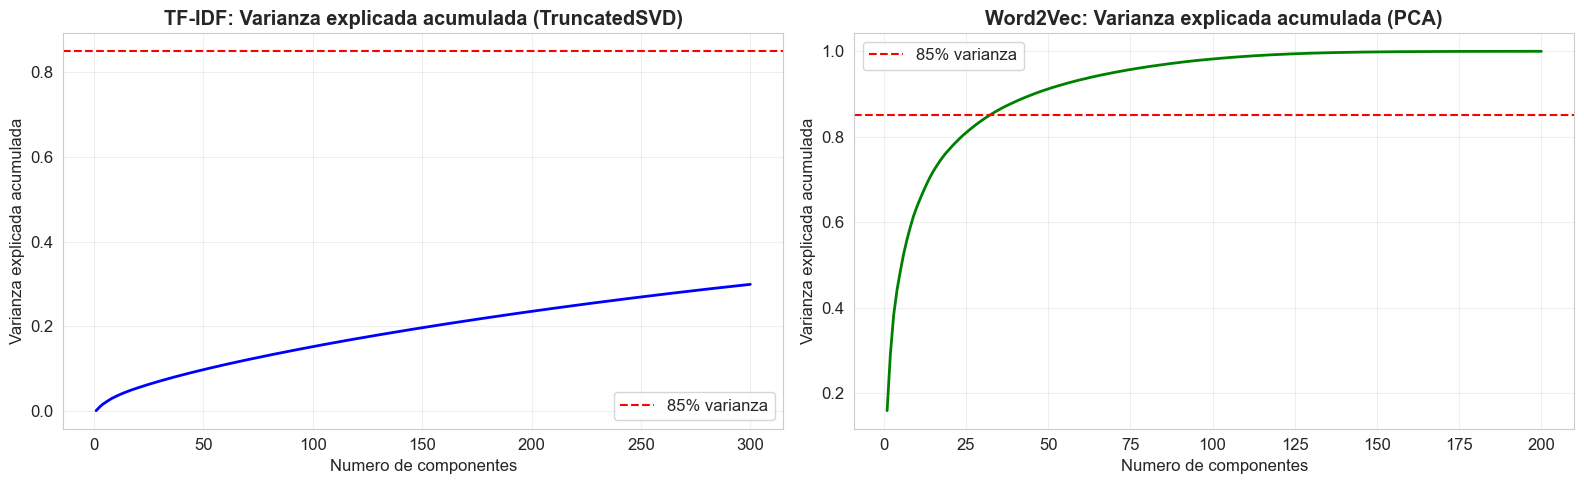

Componentes seleccionados para TF-IDF + SVD:  100 (varianza acumulada: 0.152)
Componentes seleccionados para Word2Vec + PCA: 50 (varianza acumulada: 0.912)


In [10]:
# --- Analisis de varianza explicada para seleccionar numero de componentes ---

# Para TF-IDF con TruncatedSVD
n_components_analysis = 300
svd_analysis = TruncatedSVD(n_components=n_components_analysis, random_state=RANDOM_STATE)
svd_analysis.fit(X_train_tfidf)
var_explicada_svd_tfidf = np.cumsum(svd_analysis.explained_variance_ratio_)

# Para Word2Vec con PCA
pca_analysis_w2v = PCA(n_components=min(200, X_train_w2v.shape[1]))
pca_analysis_w2v.fit(X_train_w2v)
var_explicada_pca_w2v = np.cumsum(pca_analysis_w2v.explained_variance_ratio_)

# Graficar varianza explicada acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(1, n_components_analysis + 1), var_explicada_svd_tfidf, 'b-', linewidth=2)
axes[0].axhline(y=0.85, color='r', linestyle='--', label='85% varianza')
axes[0].set_title('TF-IDF: Varianza explicada acumulada (TruncatedSVD)', fontweight='bold')
axes[0].set_xlabel('Numero de componentes')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

n_comp_w2v = len(var_explicada_pca_w2v)
axes[1].plot(range(1, n_comp_w2v + 1), var_explicada_pca_w2v, 'g-', linewidth=2)
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% varianza')
axes[1].set_title('Word2Vec: Varianza explicada acumulada (PCA)', fontweight='bold')
axes[1].set_xlabel('Numero de componentes')
axes[1].set_ylabel('Varianza explicada acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar numero optimo de componentes (>=85% varianza)
n_comp_tfidf = np.argmax(var_explicada_svd_tfidf >= 0.85) + 1
n_comp_w2v_opt = np.argmax(var_explicada_pca_w2v >= 0.85) + 1

# Asegurar un minimo razonable
n_comp_tfidf = max(n_comp_tfidf, 100)
n_comp_w2v_opt = max(n_comp_w2v_opt, 50)

print(f"Componentes seleccionados para TF-IDF + SVD:  {n_comp_tfidf} (varianza acumulada: {var_explicada_svd_tfidf[n_comp_tfidf-1]:.3f})")
print(f"Componentes seleccionados para Word2Vec + PCA: {n_comp_w2v_opt} (varianza acumulada: {var_explicada_pca_w2v[n_comp_w2v_opt-1]:.3f})")

In [11]:
# --- Aplicar reduccion de dimensionalidad: 2 combinaciones justificadas ---

# 1. TF-IDF + TruncatedSVD (LSA: la combinacion natural para matrices dispersas)
svd_tfidf = TruncatedSVD(n_components=n_comp_tfidf, random_state=RANDOM_STATE)
X_train_tfidf_svd = svd_tfidf.fit_transform(X_train_tfidf)
X_test_tfidf_svd = svd_tfidf.transform(X_test_tfidf)
print(f"1. TF-IDF + TruncatedSVD:  {X_train_tfidf_svd.shape} | Varianza explicada: {svd_tfidf.explained_variance_ratio_.sum():.3f}")

# 2. Word2Vec + PCA (la combinacion natural para embeddings densos)
pca_w2v = PCA(n_components=n_comp_w2v_opt, random_state=RANDOM_STATE)
X_train_w2v_pca = pca_w2v.fit_transform(X_train_w2v)
X_test_w2v_pca = pca_w2v.transform(X_test_w2v)
print(f"2. Word2Vec + PCA:         {X_train_w2v_pca.shape} | Varianza explicada: {pca_w2v.explained_variance_ratio_.sum():.3f}")

# Organizar los 2 datasets en un diccionario para iterar
datasets = {
    'TF-IDF + SVD':   (X_train_tfidf_svd, X_test_tfidf_svd),
    'Word2Vec + PCA': (X_train_w2v_pca, X_test_w2v_pca),
}

print("\nLos 2 datasets reducidos estan listos para clasificacion.")

1. TF-IDF + TruncatedSVD:  (7724, 100) | Varianza explicada: 0.150
2. Word2Vec + PCA:         (7724, 50) | Varianza explicada: 0.912

Los 2 datasets reducidos estan listos para clasificacion.


## 7. Modelos de clasificacion y busqueda de hiperparametros

Comparamos **2 algoritmos** de clasificacion sobre cada una de las 2 combinaciones de representacion + reduccion (TF-IDF + SVD y Word2Vec + PCA), para un total de **4 configuraciones**:

### Justificacion de los algoritmos seleccionados:

1. **Regresion Logistica:** Modelo lineal robusto que funciona muy bien en clasificacion de textos de alta dimensionalidad. Es rapido de entrenar, interpretable, y proporciona probabilidades de clase. El parametro de regularizacion `C` controla el balance sesgo-varianza.

2. **SVM (LinearSVC):** Las Maquinas de Vectores de Soporte con kernel lineal son historicamente uno de los mejores modelos para clasificacion de textos. Maximizan el margen entre clases en espacios de alta dimension, lo que les da excelente capacidad de generalizacion.

Ambos son modelos lineales, lo cual es apropiado para clasificacion de textos: la teoria y la practica demuestran que los espacios textuales de alta dimension son frecuentemente separables linealmente, y los modelos lineales generalizan mejor que los no lineales en estos escenarios.

### Busqueda de hiperparametros

Usamos `GridSearchCV` con validacion cruzada de 3 folds (para balance entre rigurosidad y tiempo de computo) y optimizamos sobre F1-macro, ya que esta metrica trata todas las clases por igual independientemente de su tamano, lo cual es apropiado dado el desbalance.

In [12]:
# Definicion de modelos y sus grids de hiperparametros
modelos = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='saga', multi_class='multinomial'),
        'params': {
            'C': [0.1, 1, 10],
        }
    },
    'SVM (LinearSVC)': {
        'model': LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto'),
        'params': {
            'C': [0.1, 1, 10],
            'loss': ['hinge', 'squared_hinge'],
        }
    }
}

print("Modelos y grids de hiperparametros definidos:")
for nombre, config in modelos.items():
    n_combinaciones = 1
    for v in config['params'].values():
        n_combinaciones *= len(v)
    print(f"  {nombre}: {n_combinaciones} combinaciones")

Modelos y grids de hiperparametros definidos:
  Logistic Regression: 3 combinaciones
  SVM (LinearSVC): 6 combinaciones


In [13]:
# --- Entrenamiento con busqueda de hiperparametros sobre las 4 combinaciones ---
resultados = []
mejores_modelos = {}

for dataset_name, (X_tr, X_te) in datasets.items():
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")

    for modelo_name, config in modelos.items():
        print(f"\n  Entrenando: {modelo_name}...", end=" ")

        grid = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=3,
            scoring='f1_macro',
            n_jobs=-1,
            refit=True
        )
        grid.fit(X_tr, y_train)

        # Evaluar en test
        y_pred = grid.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        print(f"OK | Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")
        print(f"    Mejores params: {grid.best_params_}")

        resultados.append({
            'Representacion': dataset_name,
            'Modelo': modelo_name,
            'Accuracy': acc,
            'F1-Macro': f1_macro,
            'F1-Weighted': f1_weighted,
            'Mejores Params': str(grid.best_params_),
            'CV Score (F1-macro)': grid.best_score_
        })

        # Guardar el mejor modelo de cada combinacion
        key = f"{dataset_name} | {modelo_name}"
        mejores_modelos[key] = {
            'grid': grid,
            'y_pred': y_pred,
            'dataset_name': dataset_name,
            'modelo_name': modelo_name
        }

print("\n\nEntrenamiento completado para todas las combinaciones.")


Dataset: TF-IDF + SVD

  Entrenando: Logistic Regression... 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

OK | Accuracy: 0.8732 | F1-macro: 0.8438 | F1-weighted: 0.8722
    Mejores params: {'C': 10}

  Entrenando: SVM (LinearSVC)... 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


OK | Accuracy: 0.8737 | F1-macro: 0.8443 | F1-weighted: 0.8714
    Mejores params: {'C': 1, 'loss': 'squared_hinge'}

Dataset: Word2Vec + PCA

  Entrenando: Logistic Regression... 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

OK | Accuracy: 0.8370 | F1-macro: 0.7982 | F1-weighted: 0.8362
    Mejores params: {'C': 1}

  Entrenando: SVM (LinearSVC)... 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the n

OK | Accuracy: 0.8401 | F1-macro: 0.8008 | F1-weighted: 0.8376
    Mejores params: {'C': 0.1, 'loss': 'squared_hinge'}


Entrenamiento completado para todas las combinaciones.


## 8. Evaluacion y comparacion de resultados

### Justificacion de las metricas:
- **Accuracy:** Proporcion global de predicciones correctas. Facil de interpretar pero puede ser enganosa con clases desbalanceadas.
- **F1-Macro:** Promedio del F1-score de cada clase sin ponderar por tamano. Trata todas las clases por igual, lo que penaliza modelos que ignoran clases minoritarias. Ideal para evaluar justicia entre clases.
- **F1-Weighted:** Promedio del F1-score ponderado por el numero de muestras de cada clase. Refleja el desempeno global considerando la distribucion real.
- **Matriz de confusion:** Permite visualizar exactamente donde el modelo acierta y donde confunde clases, revelando patrones de error (e.g., si confunde ODS semanticamente cercanos).

In [14]:
# Tabla comparativa de resultados
df_resultados = pd.DataFrame(resultados)
df_display = df_resultados[['Representacion', 'Modelo', 'Accuracy', 'F1-Macro', 'F1-Weighted', 'CV Score (F1-macro)']].copy()
df_display = df_display.sort_values('F1-Macro', ascending=False).reset_index(drop=True)

# Formatear numeros
for col in ['Accuracy', 'F1-Macro', 'F1-Weighted', 'CV Score (F1-macro)']:
    df_display[col] = df_display[col].map('{:.4f}'.format)

print("TABLA COMPARATIVA DE RESULTADOS (ordenada por F1-Macro descendente)")
print("=" * 95)
print(df_display.to_string(index=True))

# Identificar el mejor modelo global
mejor_idx = df_resultados['F1-Macro'].idxmax()
mejor = df_resultados.iloc[mejor_idx]
print(f"\nMEJOR COMBINACION: {mejor['Representacion']} + {mejor['Modelo']}")
print(f"  Accuracy: {mejor['Accuracy']:.4f} | F1-Macro: {mejor['F1-Macro']:.4f} | F1-Weighted: {mejor['F1-Weighted']:.4f}")
print(f"  Hiperparametros: {mejor['Mejores Params']}")

TABLA COMPARATIVA DE RESULTADOS (ordenada por F1-Macro descendente)
   Representacion               Modelo Accuracy F1-Macro F1-Weighted CV Score (F1-macro)
0    TF-IDF + SVD      SVM (LinearSVC)   0.8737   0.8443      0.8714              0.8378
1    TF-IDF + SVD  Logistic Regression   0.8732   0.8438      0.8722              0.8346
2  Word2Vec + PCA      SVM (LinearSVC)   0.8401   0.8008      0.8376              0.7894
3  Word2Vec + PCA  Logistic Regression   0.8370   0.7982      0.8362              0.7890

MEJOR COMBINACION: TF-IDF + SVD + SVM (LinearSVC)
  Accuracy: 0.8737 | F1-Macro: 0.8443 | F1-Weighted: 0.8714
  Hiperparametros: {'C': 1, 'loss': 'squared_hinge'}


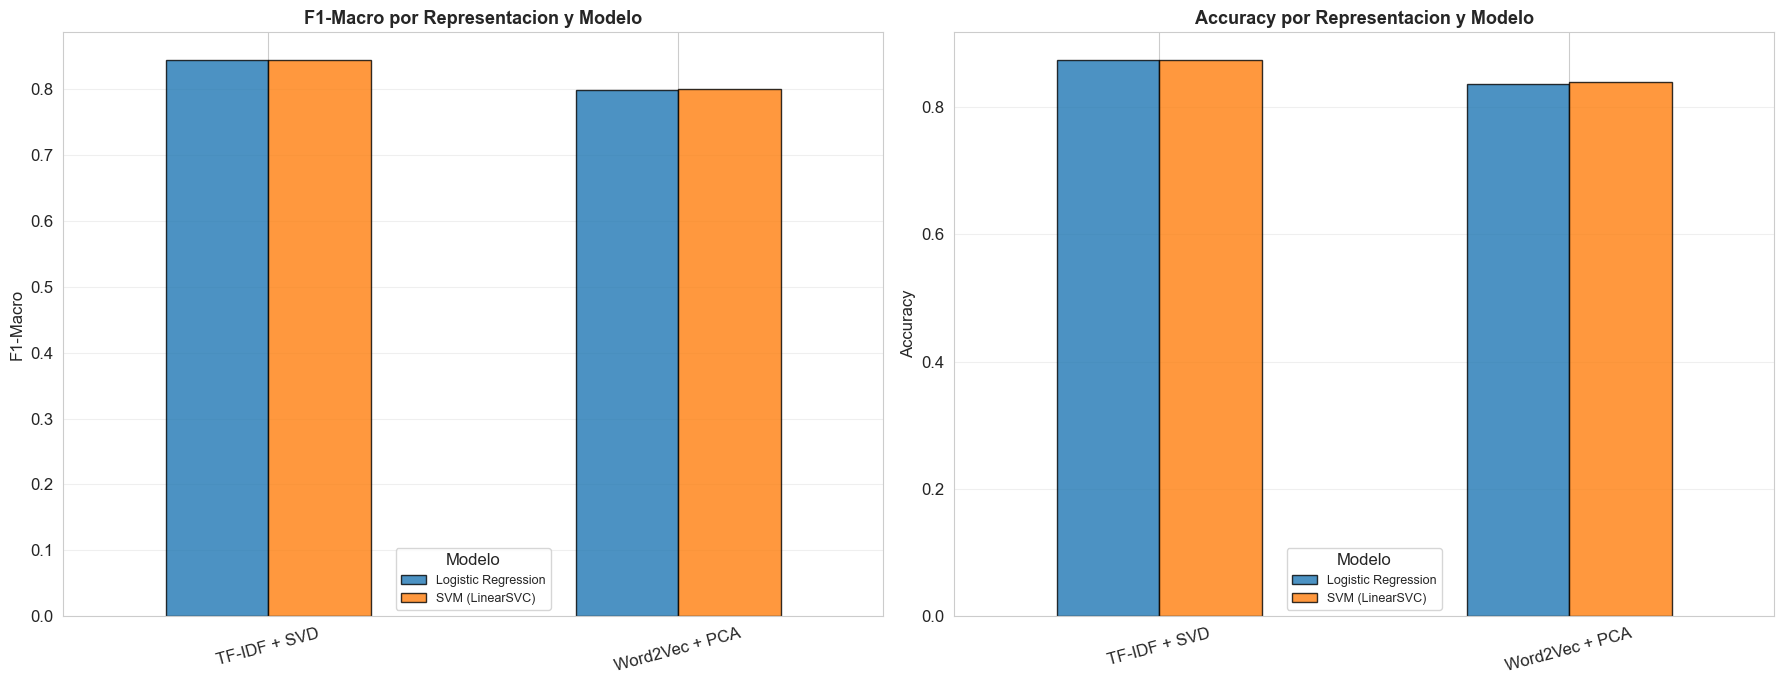

In [15]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafico de barras agrupado por metrica
df_plot = df_resultados.copy()
df_plot['Combinacion'] = df_plot['Representacion'] + '\n' + df_plot['Modelo']

# F1-Macro por combinacion
df_pivot = df_plot.pivot(index='Representacion', columns='Modelo', values='F1-Macro')
df_pivot.plot(kind='bar', ax=axes[0], edgecolor='black', alpha=0.8)
axes[0].set_title('F1-Macro por Representacion y Modelo', fontweight='bold', fontsize=13)
axes[0].set_ylabel('F1-Macro')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Modelo', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Accuracy por combinacion
df_pivot_acc = df_plot.pivot(index='Representacion', columns='Modelo', values='Accuracy')
df_pivot_acc.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.8)
axes[1].set_title('Accuracy por Representacion y Modelo', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Modelo', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

REPORTE DE CLASIFICACION - Mejor modelo: TF-IDF + SVD + SVM (LinearSVC)
              precision    recall  f1-score   support

       ODS 1       0.84      0.80      0.82       101
       ODS 2       0.75      0.84      0.79        74
       ODS 3       0.91      0.93      0.92       179
       ODS 4       0.93      0.98      0.95       205
       ODS 5       0.90      0.93      0.92       214
       ODS 6       0.93      0.92      0.92       139
       ODS 7       0.91      0.91      0.91       158
       ODS 8       0.65      0.56      0.60        89
       ODS 9       0.81      0.68      0.74        69
      ODS 10       0.80      0.63      0.70        70
      ODS 11       0.83      0.85      0.84       122
      ODS 12       0.84      0.84      0.84        62
      ODS 13       0.85      0.83      0.84        93
      ODS 14       0.89      0.91      0.90        75
      ODS 15       0.89      0.86      0.88        66
      ODS 16       0.92      0.97      0.94       216

    accu

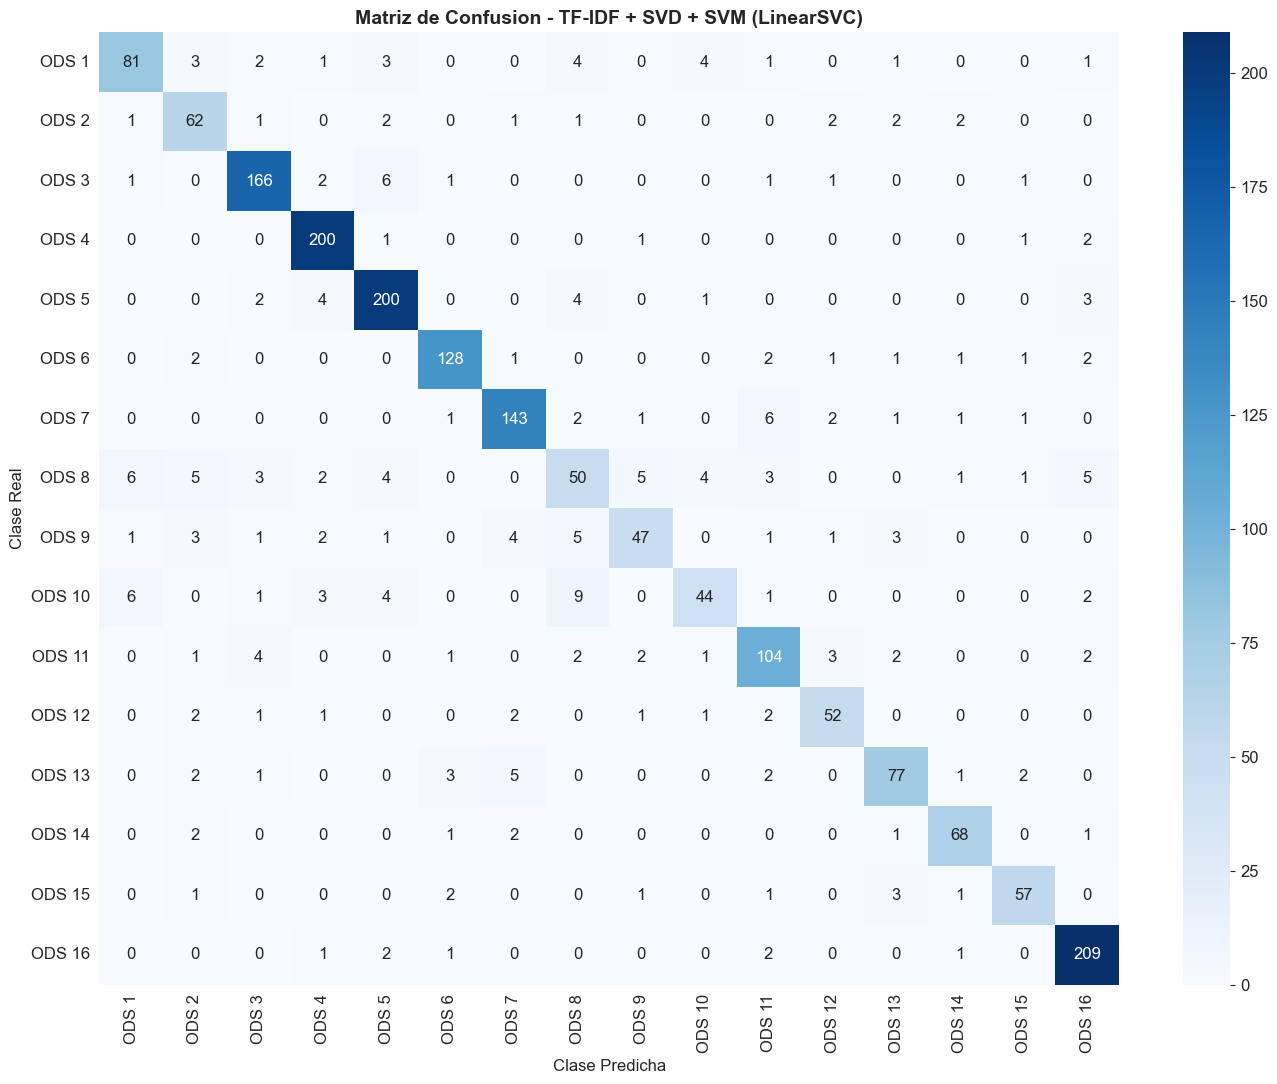

In [16]:
# --- Reporte detallado y matriz de confusion del MEJOR modelo ---
mejor_key = f"{mejor['Representacion']} | {mejor['Modelo']}"
mejor_info = mejores_modelos[mejor_key]
y_pred_mejor = mejor_info['y_pred']

print(f"REPORTE DE CLASIFICACION - Mejor modelo: {mejor['Representacion']} + {mejor['Modelo']}")
print("=" * 80)
print(classification_report(y_test, y_pred_mejor, target_names=[f"ODS {i}" for i in sorted(np.unique(y))]))

# Matriz de confusion
fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test, y_pred_mejor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f"ODS {i}" for i in sorted(np.unique(y))],
            yticklabels=[f"ODS {i}" for i in sorted(np.unique(y))])
ax.set_title(f'Matriz de Confusion - {mejor["Representacion"]} + {mejor["Modelo"]}',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Demostracion: Predicciones sobre textos del conjunto de prueba

A continuacion mostramos las predicciones del mejor modelo para **al menos 4 textos** del conjunto de prueba que **no fueron utilizados durante el entrenamiento**. Para cada texto se muestra:
- El texto original (truncado para legibilidad)
- La clase real (ODS verdadero)
- La clase predicha por el modelo
- Si la prediccion fue correcta o no

Esto evidencia el desempeno practico del modelo en un escenario real de uso.

In [17]:
# Seleccionar textos de prueba de diferentes clases para la demostracion
# Elegimos al menos 6 textos: algunos correctos y algunos incorrectos para mostrar diversidad
np.random.seed(RANDOM_STATE)

# Tomar indices de predicciones correctas e incorrectas
correctos = np.where(y_pred_mejor == y_test)[0]
incorrectos = np.where(y_pred_mejor != y_test)[0]

# Seleccionar 4 correctos y 2 incorrectos (si los hay)
idx_demo = list(np.random.choice(correctos, size=min(4, len(correctos)), replace=False))
if len(incorrectos) > 0:
    idx_demo += list(np.random.choice(incorrectos, size=min(2, len(incorrectos)), replace=False))

print(f"DEMOSTRACION DE PREDICCIONES ({len(idx_demo)} textos del conjunto de prueba)")
print("=" * 100)

for i, idx in enumerate(idx_demo, 1):
    texto_original = X_test_orig[idx]
    real = y_test[idx]
    predicho = y_pred_mejor[idx]
    correcto = "CORRECTO" if real == predicho else "INCORRECTO"

    print(f"\n--- Texto {i} ---")
    print(f"Texto (primeros 250 chars): {texto_original[:250]}...")
    print(f"  ODS Real:     {real:2d} - {ODS_NOMBRES[real]}")
    print(f"  ODS Predicho: {predicho:2d} - {ODS_NOMBRES[predicho]}")
    print(f"  Resultado:    {correcto}")

DEMOSTRACION DE PREDICCIONES (6 textos del conjunto de prueba)

--- Texto 1 ---
Texto (primeros 250 chars): Sin embargo, en todos los países, los riesgos y vulnerabilidades asociados con la economía informal (Capítulo 3) afectan de manera desproporcionada a las mujeres. Este capítulo proporciona evidencia actualizada sobre las disparidades de género en los...
  ODS Real:      5 - Igualdad de genero
  ODS Predicho:  5 - Igualdad de genero
  Resultado:    CORRECTO

--- Texto 2 ---
Texto (primeros 250 chars): Así pues, los PEID disponen del espacio oceánico con sus recursos vivos y no vivos que pueden desarrollarse de forma sostenible para apoyar el crecimiento económico, el comercio y el desarrollo. En la actualidad, se están dando algunos pasos, especia...
  ODS Real:     14 - Vida submarina
  ODS Predicho: 14 - Vida submarina
  Resultado:    CORRECTO

--- Texto 3 ---
Texto (primeros 250 chars): La relevancia política de la metáfora del agua virtual será mayor donde los valores de escas

## 10. Exportacion del mejor modelo para despliegue (Streamlit)

Guardamos el mejor modelo junto con todos los componentes necesarios del pipeline para poder reutilizarlo en la aplicacion Streamlit sin necesidad de reentrenar. Esto incluye:
- El preprocesador de texto
- El vectorizador (TF-IDF o Word2Vec)
- El reductor de dimensionalidad
- El clasificador entrenado

In [18]:
# Determinar que componentes guardar segun la mejor combinacion
mejor_repr = mejor['Representacion']
mejor_modelo_name = mejor['Modelo']
mejor_grid = mejores_modelos[mejor_key]['grid']

# Construir diccionario con todos los artefactos necesarios
artefactos = {
    'preprocessor': preprocessor,
    'clasificador': mejor_grid.best_estimator_,
    'representacion': mejor_repr,
    'ods_nombres': ODS_NOMBRES,
}

# Agregar componentes especificos segun la representacion ganadora
if 'TF-IDF' in mejor_repr:
    artefactos['vectorizer'] = tfidf_vectorizer
    artefactos['reductor'] = svd_tfidf
else:  # Word2Vec + PCA
    artefactos['w2v_model'] = w2v_model
    artefactos['reductor'] = pca_w2v

# Guardar
joblib.dump(artefactos, 'modelo_ods.joblib')
print(f"Modelo guardado en 'modelo_ods.joblib'")
print(f"Representacion: {mejor_repr}")
print(f"Clasificador: {mejor_modelo_name}")
print(f"Componentes guardados: {list(artefactos.keys())}")

Modelo guardado en 'modelo_ods.joblib'
Representacion: TF-IDF + SVD
Clasificador: SVM (LinearSVC)
Componentes guardados: ['preprocessor', 'clasificador', 'representacion', 'ods_nombres', 'vectorizer', 'reductor']


## 11. Conclusiones

### Resumen de resultados

| Representacion + Reduccion | Modelo | Accuracy | F1-Macro | F1-Weighted |
|---|---|---|---|---|
| **TF-IDF + SVD** | **SVM (LinearSVC)** | **0.8737** | **0.8443** | **0.8714** |
| TF-IDF + SVD | Logistic Regression | 0.8732 | 0.8438 | 0.8722 |
| Word2Vec + PCA | SVM (LinearSVC) | 0.8401 | 0.8008 | 0.8376 |
| Word2Vec + PCA | Logistic Regression | 0.8370 | 0.7982 | 0.8362 |

El mejor modelo fue **TF-IDF + TruncatedSVD + SVM (LinearSVC)** con `C=1` y `loss=squared_hinge`, logrando un **87.4% de accuracy** y **0.844 de F1-macro**.

### Por que TF-IDF supera a Word2Vec en esta tarea

TF-IDF supera consistentemente a Word2Vec por ~4 puntos porcentuales en F1-macro (0.844 vs 0.800). Esto no es una anomalia sino un resultado esperado para tareas de **clasificacion tematica**, y se explica por las siguientes razones:

1. **La clasificacion por ODS depende de indicadores lexicos, no de similitud semantica.** Cada ODS tiene un vocabulario distintivo: "genero", "mujer" para ODS 5; "oceano", "marin" para ODS 14; "energia", "renov" para ODS 7. TF-IDF codifica directamente la presencia e importancia de estas palabras clave. Word2Vec, al capturar que "pobreza" y "desigualdad" son semanticamente cercanas, en realidad *dificulta* la distincion entre ODS 1 (Fin de la pobreza) y ODS 10 (Reduccion de desigualdades), que es precisamente donde necesitamos discriminar.

2. **La perdida de informacion por promediado.** Word2Vec representa cada documento como el **promedio** de los vectores de sus palabras. Esta operacion destruye las senales discriminativas individuales: un texto largo con muchas palabras generales sobre desarrollo sostenible diluye las pocas palabras clave que indicarian el ODS correcto. TF-IDF, en cambio, preserva el peso especifico de cada termino.

3. **Los bigramas capturan frases discriminativas.** Configuramos TF-IDF con `ngram_range=(1,2)`, lo que permite capturar frases como "cambio climatico" (ODS 13), "igualdad genero" (ODS 5) o "vida submarina" (ODS 14). Estos bigramas son altamente discriminativos. Word2Vec con promediado pierde completamente la informacion de orden y colocacion de las palabras.

4. **Tamano del corpus para Word2Vec.** Word2Vec necesita grandes volumenes de texto para aprender embeddings de calidad. Con ~7,700 textos de entrenamiento (un corpus relativamente pequeno), el modelo tiene contexto limitado para aprender relaciones semanticas matizadas. TF-IDF no tiene esta limitacion: funciona bien incluso con corpus de tamano moderado porque sus pesos se calculan con estadisticas simples de frecuencia.

En resumen: **Word2Vec es mas complejo, pero esa complejidad no se traduce en mejor desempeno para esta tarea.** La clasificacion tematica de textos se beneficia mas de identificar *que palabras aparecen* (lo que TF-IDF hace bien) que de entender *que significan* (lo que Word2Vec intenta hacer). La complejidad adicional de Word2Vec solo se justificaria en tareas donde la sinonimia y las relaciones semanticas sean criticas, como deteccion de parafraseo o analisis de sentimiento.

### Observaciones adicionales
- Ambos modelos lineales (LR y SVM) tuvieron desempeno casi identico en TF-IDF + SVD (0.8438 vs 0.8443 en F1-macro), lo que confirma que el espacio reducido por SVD es linealmente separable.
- Las clases con peor desempeno fueron ODS 8 (Trabajo decente, F1=0.60) y ODS 10 (Desigualdades, F1=0.70), lo que tiene sentido: sus temas se solapan con otros ODS (pobreza, crecimiento economico) y son las clases mas pequeñas del dataset.
- La reduccion de dimensionalidad fue efectiva: TF-IDF paso de 10,000 features a 100 componentes reteniendo la informacion discriminativa necesaria para alcanzar 87% de accuracy.